# <center>**Tecnológico de Costa Rica**</center>

***IC-6200 / Inteligencia artificial***

Profesor

*   **Efren Jimenez Delgado**

Proyecto JarvisTEC, I Semestre 2026

## Análisis del Problema

La calidad de un vino se decide con una cata sensorial, un proceso lento, caro y subjetivo. Queremos estimarla a partir de sus propiedades fisicoquímicas, que se miden en laboratorio de forma objetiva (Cortez et al., 2009).

Es un problema de **clasificación multiclase supervisada**. La puntuación sensorial (`quality`, de 3 a 9) se agrupa en tres clases ordenadas: **baja** (5 o menos), **media** (6) y **alta** (7 o más). La agrupación es necesaria porque los extremos casi no tienen ejemplos.

El asistente JarvisTEC usa este modelo para responder a la pregunta "qué calidad tiene este vino" con las 12 variables que el usuario escribe en un formulario.

# Caso Aplicado: Calidad del Vino
## Clasificación multiclase con validación cruzada estratificada

---

**Temas:** Filas duplicadas · Valores nulos · Estratificación · Regresión logística, SVM, Random Forest y Gradient Boosting · F1 macro  
**Herramientas:** Python · Pandas · Scikit-learn · Seaborn

---

### El hilo conductor

| Etapa | Pregunta central |
|---|---|
| 1 — Entendimiento y limpieza | ¿Hay filas duplicadas o valores faltantes que distorsionen la evaluación? |
| 2 — Exploración | ¿Qué propiedades separan los vinos de calidad baja, media y alta? |
| 3 — Modelo | ¿Qué clasificador rinde mejor y cómo se compara con predecir siempre la clase más común? |
| 4 — Evaluación | ¿En qué clases se equivoca el modelo y qué tan grave es el error? |

> Nota: el objetivo no es solo obtener una buena exactitud. Hay que asegurarse de que la métrica sea honesta, y las filas duplicadas pueden inflarla sin que el modelo aprenda nada.

Este notebook es un extra del modelo 03 del proyecto: reproduce de forma didáctica el entrenamiento que hace `train.py` y se puede probar en Google Colab. No reemplaza al código del repositorio.

### Autores

   * Equipo JarvisTEC (proyecto de la primera etapa)

### Librerías

In [1]:
# Manejo de datasets
import pandas as pd
import numpy as np
# Gráficos
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
# Modelos
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import RepeatedStratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import SVC
# Ignorar Warnings
import warnings
warnings.filterwarnings('ignore')

SEMILLA = 42

---
# Sección 1: Entendimiento de los Datos
---

## Entendimiento de los Datos

El conjunto tiene muestras de vinho verde portugués, tinto y blanco (Cortez et al., 2009). Las variables son:

- type                 : variable cualitativa nominal, `red` o `white`
- fixed acidity, volatile acidity, citric acid : acidez fija, acidez volátil y ácido cítrico
- residual sugar       : azúcar residual
- chlorides            : cloruros
- free sulfur dioxide, total sulfur dioxide : dióxido de azufre libre y total
- density, pH, sulphates, alcohol : densidad, pH, sulfatos y alcohol
- quality              : puntuación sensorial de 3 a 9, de la que sale la variable objetivo

Los datos están en el archivo `dataset.csv` de la carpeta `backend/features/modelo_03_vino/` del repositorio. Son 6 497 filas y 13 columnas.

En Colab hay dos formas de usarlo: arrastrarlo al panel de archivos (queda en `sample_data/`) o subirlo cuando la celda lo pida.

In [2]:
# Ubicar el archivo de datos (Colab o ejecución local)
import os

RUTA = next((r for r in ("sample_data/dataset.csv", "dataset.csv") if os.path.exists(r)), None)
if RUTA is None:
    try:
        from google.colab import files
        print("Seleccione el archivo dataset.csv")
        RUTA = next(iter(files.upload()))
    except ImportError:
        raise FileNotFoundError("No se encontró dataset.csv: colóquelo en sample_data/ o en la carpeta actual")
print("Archivo de datos:", RUTA)

Archivo de datos: sample_data/dataset.csv


In [3]:
# Cargar los datos
crudo = pd.read_csv(RUTA)
crudo.head()

,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,white,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,white,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,white,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,white,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,white,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


In [4]:
# Información del dataset
crudo.info()

<class 'pandas.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   type                  6497 non-null   str    
 1   fixed acidity         6487 non-null   float64
 2   volatile acidity      6489 non-null   float64
 3   citric acid           6494 non-null   float64
 4   residual sugar        6495 non-null   float64
 5   chlorides             6495 non-null   float64
 6   free sulfur dioxide   6497 non-null   float64
 7   total sulfur dioxide  6497 non-null   float64
 8   density               6497 non-null   float64
 9   pH                    6488 non-null   float64
 10  sulphates             6493 non-null   float64
 11  alcohol               6497 non-null   float64
 12  quality               6497 non-null   int64  
dtypes: float64(11), int64(1), str(1)
memory usage: 660.0 KB


In [5]:
print("Filas y columnas:", crudo.shape)
print("Tipos de vino:", crudo["type"].value_counts().to_dict())
print("Puntuación (quality):", crudo["quality"].value_counts().sort_index().to_dict())

Filas y columnas: (6497, 13)
Tipos de vino: {'white': 4898, 'red': 1599}
Puntuación (quality): {3: 30, 4: 216, 5: 2138, 6: 2836, 7: 1079, 8: 193, 9: 5}


### Filas duplicadas

Es importante revisar los duplicados **antes** de dividir en entrenamiento y prueba. Si la misma muestra cae en los dos conjuntos, la métrica mide la memoria del modelo y no su capacidad de generalizar.

In [6]:
duplicadas = int(crudo.duplicated().sum())
print("Filas duplicadas:", duplicadas, "(%.0f %%)" % (100 * duplicadas / len(crudo)))

def preparar(datos):
    df = datos.copy()
    df.columns = [c.replace(" ", "_").lower() for c in df.columns]
    df = df.rename(columns={"type": "tipo"})
    df["clase"] = np.where(df["quality"] <= 5, "baja", np.where(df["quality"] == 6, "media", "alta"))
    return df

df = preparar(crudo.drop_duplicates().reset_index(drop=True))
print("Filas sin duplicados:", len(df))
print("Tipos:", df["tipo"].value_counts().to_dict())

Filas duplicadas: 1168 (18 %)
Filas sin duplicados: 5329
Tipos: {'white': 3970, 'red': 1359}


### Valores nulos

In [7]:
NUMERICAS = ["fixed_acidity", "volatile_acidity", "citric_acid", "residual_sugar", "chlorides", "free_sulfur_dioxide",
             "total_sulfur_dioxide", "density", "ph", "sulphates", "alcohol"]
CATEGORICAS = ["tipo"]
VARIABLES = NUMERICAS + CATEGORICAS
OBJETIVO = "clase"
ORDEN = ["baja", "media", "alta"]

nulos = df[VARIABLES].isna().sum()
print("Nulos por columna:", nulos[nulos > 0].to_dict())
print("Filas con algún nulo:", int(df[VARIABLES].isna().any(axis=1).sum()), "de", len(df))
print("Clases:", df[OBJETIVO].value_counts(normalize=True).round(3).reindex(ORDEN).to_dict())

Nulos por columna: {'fixed_acidity': 10, 'volatile_acidity': 8, 'citric_acid': 3, 'residual_sugar': 2, 'chlorides': 2, 'ph': 9, 'sulphates': 4}
Filas con algún nulo: 34 de 5329
Clases: {'baja': 0.374, 'media': 0.437, 'alta': 0.19}


Son pocos nulos (menos del 1 % de las filas). Se imputan con la mediana **dentro del Pipeline**, de modo que en cada pliegue de validación la mediana se calcule solo con los datos de entrenamiento de ese pliegue.

Las clases están moderadamente desbalanceadas, así que la métrica principal es el **F1 macro** (promedia el F1 de cada clase con el mismo peso).

---
# Sección 2: Exploración de los Datos
---

## Exploración de los Datos

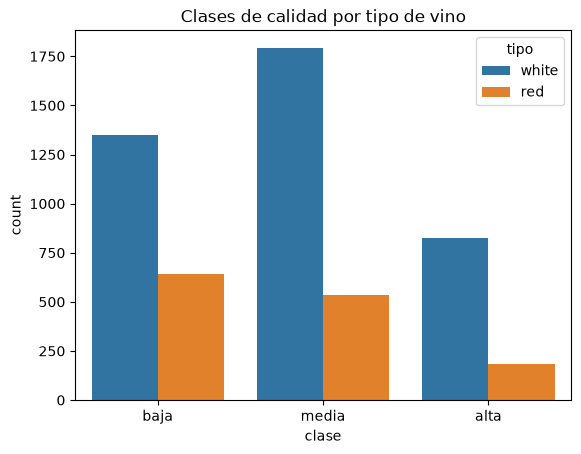

clase,baja,media,alta
tipo,,,
red,0.47,0.39,0.14
white,0.34,0.45,0.21


In [8]:
sns.countplot(data=df, x=OBJETIVO, hue="tipo", order=ORDEN)
plt.title("Clases de calidad por tipo de vino")
plt.show()
pd.crosstab(df["tipo"], df[OBJETIVO], normalize="index").round(2).reindex(columns=ORDEN)

Los vinos tintos concentran más calidad baja que los blancos, y los blancos tienen más calidad alta.

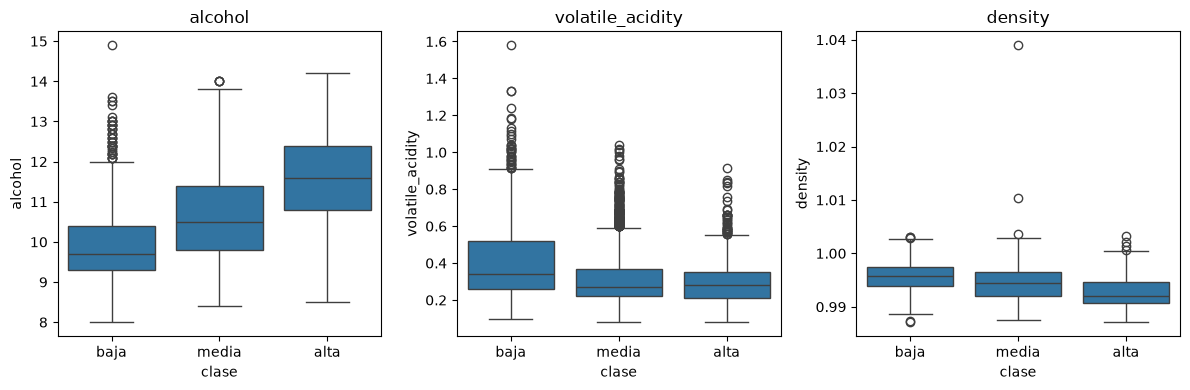

,alcohol,volatile_acidity,density
clase,,,
baja,9.7,0.34,0.996
media,10.5,0.27,0.994
alta,11.6,0.28,0.992


In [9]:
fig, ejes = plt.subplots(1, 3, figsize=(12, 4))
for eje, variable in zip(ejes, ["alcohol", "volatile_acidity", "density"]):
    sns.boxplot(data=df, x=OBJETIVO, y=variable, order=ORDEN, ax=eje)
    eje.set_title(variable)
plt.tight_layout()
plt.show()
df.groupby(OBJETIVO)[["alcohol", "volatile_acidity", "density"]].median().reindex(ORDEN).round(3)

El **alcohol** es la variable que más separa las clases: sube a medida que sube la calidad. La acidez volátil es mayor en los vinos de calidad baja y la densidad baja al subir la calidad.

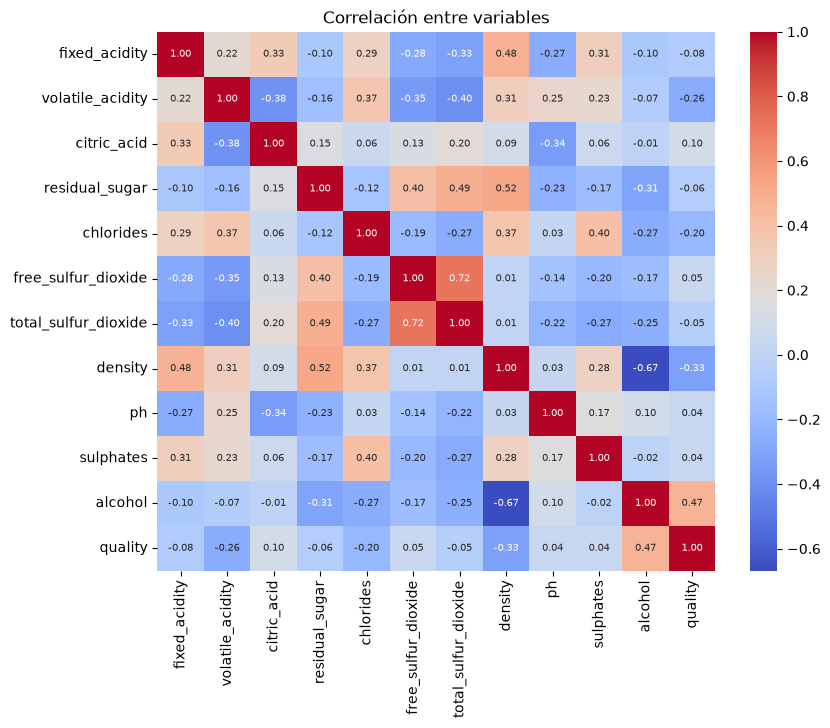

density                -0.33
volatile_acidity       -0.26
chlorides              -0.20
fixed_acidity          -0.08
residual_sugar         -0.06
total_sulfur_dioxide   -0.05
ph                      0.04
sulphates               0.04
free_sulfur_dioxide     0.05
citric_acid             0.10
alcohol                 0.47
Name: quality, dtype: float64

In [10]:
corr = df[NUMERICAS + ["quality"]].corr()
plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", annot_kws={"size": 7})
plt.title("Correlación entre variables")
plt.show()
corr["quality"].drop("quality").sort_values().round(2)

> Analogía: el alcohol y la densidad se parecen a dos testigos que cuentan casi la misma historia. El alcohol baja la densidad del vino, así que las dos variables están muy relacionadas entre sí y aportan información parcialmente repetida.

Las correlaciones más altas con la puntuación son el alcohol (positiva) y la densidad y la acidez volátil (negativas). Algunos valores extremos, como un azúcar residual de 65.8 g/dm3, son mediciones posibles y se conservan.

---
# Sección 3: Ajuste del Modelo
---

## Modelo de Machine Learning

La división es **estratificada**: conserva la proporción de las tres clases en entrenamiento y prueba.

In [11]:
X, y = df[VARIABLES], df[OBJETIVO]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=SEMILLA)
print("Entrenamiento:", X_train.shape, " Prueba:", X_test.shape)
pd.DataFrame({"entrenamiento": y_train.value_counts(normalize=True), "prueba": y_test.value_counts(normalize=True)}).reindex(ORDEN).round(3)

Entrenamiento: (4263, 12)  Prueba: (1066, 12)


,entrenamiento,prueba
clase,,
baja,0.374,0.373
media,0.437,0.437
alta,0.190,0.189


> Es importante siempre validar los rangos de los conjuntos creados, para evitar caer en extrapolación:

In [12]:
pd.DataFrame({"entrenamiento_min": X_train[NUMERICAS].min(), "entrenamiento_max": X_train[NUMERICAS].max(),
              "prueba_min": X_test[NUMERICAS].min(), "prueba_max": X_test[NUMERICAS].max()}).round(3)

,entrenamiento_min,entrenamiento_max,prueba_min,prueba_max
fixed_acidity,3.900,15.90,3.800,15.600
volatile_acidity,0.080,1.58,0.100,1.330
citric_acid,0.000,1.66,0.000,0.820
residual_sugar,0.600,31.60,0.700,65.800
chlorides,0.009,0.61,0.015,0.611
free_sulfur_dioxide,1.000,146.50,2.000,289.000
total_sulfur_dioxide,6.000,313.00,6.000,440.000
density,0.987,1.01,0.987,1.039
ph,2.720,4.01,2.790,3.850
sulphates,0.250,2.00,0.220,1.950


### Candidatos

Cada candidato es un `Pipeline` con imputación de nulos, escalado (cuando hace falta) y codificación del tipo de vino. La línea base siempre predice la clase más frecuente. La selección usa **solo el entrenamiento**, con validación cruzada estratificada repetida (5 particiones por 2 repeticiones) y F1 macro como criterio.

In [13]:
def armar(estimador, escalar=True):
    numericas = Pipeline([("imputar", SimpleImputer(strategy="median"))] + ([("escala", StandardScaler())] if escalar else []))
    columnas = ColumnTransformer([
        ("num", numericas, NUMERICAS),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), CATEGORICAS),
    ])
    return Pipeline([("pre", columnas), ("modelo", estimador)])

def candidatos():
    return {
        "mayoritaria (línea base)": armar(DummyClassifier(strategy="most_frequent")),
        "regresión logística": armar(LogisticRegression(max_iter=3000, class_weight="balanced")),
        "svm rbf": armar(SVC(C=3, class_weight="balanced", random_state=SEMILLA)),
        "random forest": armar(RandomForestClassifier(n_estimators=100, min_samples_leaf=5, max_depth=16,
                                                      class_weight="balanced_subsample", random_state=SEMILLA, n_jobs=-1), escalar=False),
        "gradient boosting": armar(HistGradientBoostingClassifier(max_iter=200, learning_rate=0.08, class_weight="balanced",
                                                                  early_stopping=False, random_state=SEMILLA), escalar=False),
    }

validacion = RepeatedStratifiedKFold(n_splits=5, n_repeats=2, random_state=SEMILLA)
filas = {}
for nombre, pipe in candidatos().items():
    r = cross_validate(pipe, X_train, y_train, cv=validacion, scoring={"f1": "f1_macro", "acc": "accuracy"})
    filas[nombre] = {"F1 macro cv": r["test_f1"].mean(), "desviación": r["test_f1"].std(), "exactitud cv": r["test_acc"].mean()}
comparacion = pd.DataFrame(filas).T.round(3)
comparacion

,F1 macro cv,desviación,exactitud cv
mayoritaria (línea base),0.203,0.000,0.437
regresión logística,0.554,0.012,0.559
svm rbf,0.567,0.019,0.572
random forest,0.595,0.012,0.602
gradient boosting,0.586,0.016,0.598


Random Forest y Gradient Boosting casi no se distinguen (la diferencia es menor que la variación entre pliegues). La regresión logística y la SVM quedan por detrás. La SVM no se optimizó (se usó C = 3 fijo), así que su resultado puede mejorar.

In [14]:
# Solo pueden elegirse candidatos que calculan probabilidades (la API las devuelve): la SVM sin probability no es elegible.
elegibles = [n for n, pipe in candidatos().items() if "línea base" not in n and hasattr(pipe, "predict_proba")]
ganador = comparacion.loc[elegibles, "F1 macro cv"].idxmax()
print("Modelo elegido:", ganador)
modelo = candidatos()[ganador].fit(X_train, y_train)

Modelo elegido: random forest


##### Evaluación en el conjunto de prueba

In [15]:
y_pred = modelo.predict(X_test)
base = candidatos()["mayoritaria (línea base)"].fit(X_train, y_train).predict(X_test)
pd.DataFrame({"mayoritaria (línea base)": {"exactitud": accuracy_score(y_test, base), "F1 macro": f1_score(y_test, base, average="macro")},
              ganador: {"exactitud": accuracy_score(y_test, y_pred), "F1 macro": f1_score(y_test, y_pred, average="macro")}}).T.round(3)

,exactitud,F1 macro
mayoritaria (línea base),0.437,0.203
random forest,0.594,0.591


              precision    recall  f1-score   support

        baja      0.660     0.701     0.680       398
       media      0.572     0.485     0.525       466
        alta      0.516     0.634     0.569       202

    accuracy                          0.594      1066
   macro avg      0.583     0.607     0.591      1066
weighted avg      0.594     0.594     0.591      1066



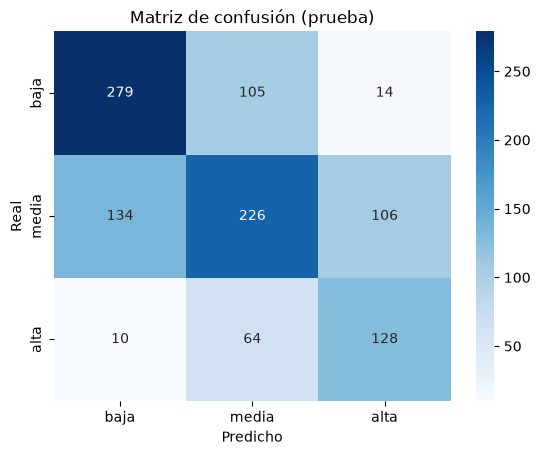

Errores: 433 | entre clases vecinas: 409 (94 %)


In [16]:
print(classification_report(y_test, y_pred, labels=ORDEN, digits=3))
matriz = confusion_matrix(y_test, y_pred, labels=ORDEN)
sns.heatmap(matriz, annot=True, fmt="d", cmap="Blues", xticklabels=ORDEN, yticklabels=ORDEN)
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title("Matriz de confusión (prueba)")
plt.show()
errores = matriz.sum() - np.trace(matriz)
vecinos = matriz[0, 1] + matriz[1, 0] + matriz[1, 2] + matriz[2, 1]
print("Errores:", errores, "| entre clases vecinas:", vecinos, "(%.0f %%)" % (100 * vecinos / errores))

El F1 de prueba es parecido al de validación cruzada, así que no hay indicio de sobreajuste a la selección. Los errores son casi todos entre clases vecinas: el modelo casi nunca confunde un vino bajo con uno alto. La clase "media" es la más difícil, como se espera de la clase intermedia de una escala ordinal.

### Experimento: qué pasa si no se quitan los duplicados

Se repite el mismo entrenamiento dejando las filas duplicadas.

In [17]:
crudo_p = preparar(crudo)
Xc_tr, Xc_te, yc_tr, yc_te = train_test_split(crudo_p[VARIABLES], crudo_p[OBJETIVO], test_size=0.2, stratify=crudo_p[OBJETIVO], random_state=SEMILLA)
inflado = clone(candidatos()[ganador]).fit(Xc_tr, yc_tr)
copias = Xc_te.merge(Xc_tr.drop_duplicates(), on=VARIABLES, how="left", indicator=True)["_merge"].eq("both")
print("Exactitud con duplicados: %.3f   sin duplicados: %.3f" % (accuracy_score(yc_te, inflado.predict(Xc_te)), accuracy_score(y_test, y_pred)))
print("Filas de prueba con una copia exacta en el entrenamiento: %d de %d" % (copias.sum(), len(Xc_te)))

Exactitud con duplicados: 0.695   sin duplicados: 0.594
Filas de prueba con una copia exacta en el entrenamiento: 356 de 1300


La exactitud sube unos 10 puntos solo por memoria: no es una mejora real. Por eso se descartan los duplicados antes de dividir. Las dos particiones no son idénticas, así que no es una comparación pareada, pero el efecto es claro.

### Predicción para un vino nuevo

In [18]:
vino = pd.DataFrame([{"fixed_acidity": 7.0, "volatile_acidity": 0.3, "citric_acid": 0.3, "residual_sugar": 2.0, "chlorides": 0.045,
                      "free_sulfur_dioxide": 30, "total_sulfur_dioxide": 120, "density": 0.994, "ph": 3.2, "sulphates": 0.5,
                      "alcohol": 11.5, "tipo": "white"}])
print("Calidad estimada:", modelo.predict(vino[VARIABLES])[0])
print({clase: round(float(p), 3) for clase, p in zip(modelo.classes_, modelo.predict_proba(vino[VARIABLES])[0])})

Calidad estimada: media
{'alta': 0.401, 'baja': 0.192, 'media': 0.406}


---
# Conclusiones
---

## Resultados

Con las propiedades fisicoquímicas se puede clasificar la calidad del vino con una exactitud de alrededor de 0.59 y un F1 macro de alrededor de 0.59 (el último decimal puede variar según la versión de scikit-learn), frente a 0.44 y 0.20 de la clase mayoritaria. Sirve como orientación pero no reemplaza a la cata: los errores graves son raros, pero cerca de 4 de cada 10 vinos reciben una clase vecina equivocada. El alcohol, la acidez volátil y la densidad son las variables más informativas.

El hallazgo metodológico principal es la fuga por filas duplicadas: sin eliminarlas, la exactitud parece unos 10 puntos mejor.

Limitaciones: la puntuación sensorial es subjetiva y pone un techo a lo que se puede predecir. Solo hay vinos verdes portugueses, así que el modelo no sirve para otras regiones. La SVM y los hiperparámetros del bosque no se optimizaron a fondo, y la prueba es una sola partición.

### Referencias

> Cortez, P., Cerdeira, A., Almeida, F., Matos, T., & Reis, J. (2009). Modeling wine preferences by data mining from physicochemical properties. *Decision Support Systems*, 47(4), 547-553.
> Breiman, L. (2001). Random forests. *Machine Learning*, 45(1), 5-32.
> Sokolova, M., & Lapalme, G. (2009). A systematic analysis of performance measures for classification tasks. *Information Processing & Management*, 45(4), 427-437.